# Sistema Inteligente de Priorização de Processos Jurídicos

## Importação das Bibliotecas

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
from sklearn.datasets import load_breast_cancer

## Carregamento do Dataset

In [46]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

In [48]:
from sklearn.preprocessing import StandardScaler

df['mean radius'] = StandardScaler().fit_transform(df[['mean radius']])

In [49]:
df = df[df['mean area'] > 50]

In [52]:
X = df.drop('target', axis=1)
y = df['target']

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

In [53]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,1.097064,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1.829821,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,1.579888,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,-0.768909,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,1.750297,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Análise Exploratória dos Dados

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   valor_causa   15 non-null     int64 
 1   dias_prazo    15 non-null     int64 
 2   urgencia      15 non-null     int64 
 3   qtd_partes    15 non-null     int64 
 4   tempo_parado  15 non-null     int64 
 5   prioridade    15 non-null     object
dtypes: int64(5), object(1)
memory usage: 852.0+ bytes


In [5]:
df.describe()

,valor_causa,dias_prazo,urgencia,qtd_partes,tempo_parado
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,38066.666667,23.266667,0.333333,2.666667,17.533333
std,45276.478704,21.805853,0.487950,1.290994,17.541244
min,2000.000000,1.000000,0.000000,1.000000,0.000000
25%,3750.000000,3.500000,0.000000,2.000000,2.500000
50%,14000.000000,15.000000,0.000000,2.000000,11.000000
75%,83500.000000,46.500000,1.000000,3.500000,32.500000
max,120000.000000,60.000000,1.000000,5.000000,50.000000


In [6]:
df.isnull().sum()

,0
valor_causa,0
dias_prazo,0
urgencia,0
qtd_partes,0
tempo_parado,0
prioridade,0


## Transformação dos Dados

In [7]:
le = LabelEncoder()

df['prioridade'] = le.fit_transform(df['prioridade'])

In [8]:
df.head()

,valor_causa,dias_prazo,urgencia,qtd_partes,tempo_parado,prioridade
0,80000,2,1,4,1,0
1,15000,15,0,2,10,2
2,3000,45,0,2,40,1
3,120000,1,1,5,0,0
4,7000,20,0,2,15,2


In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(15, 6)

In [11]:
X = df.drop('prioridade', axis=1)

In [13]:
y = df['prioridade']

## Separação dos Dados

Os dados foram divididos em treino e teste (70/30) e posteriormente em validação, garantindo uma avaliação mais robusta do modelo de Machine Learning.

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

## Treinamento do Modelo

In [15]:
model = DecisionTreeClassifier()

Acurácia: 0.9186046511627907


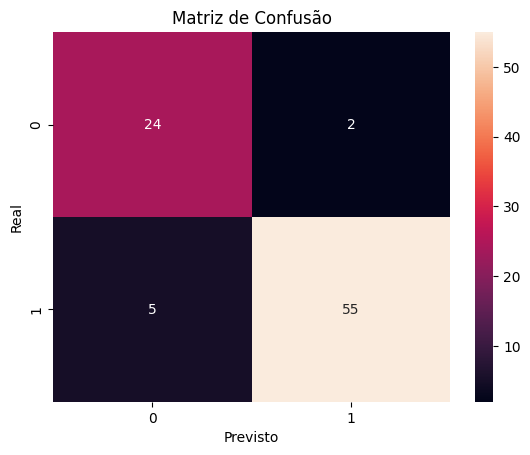

In [54]:
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")

plt.show()

In [28]:
y_pred = model.predict(X_test)

## Avaliação do Modelo

In [29]:
acc = accuracy_score(y_test, y_pred)

print("Acurácia:", acc)

Acurácia: 1.0


## Matriz de Confusão

In [30]:
cm = confusion_matrix(y_test, y_pred)

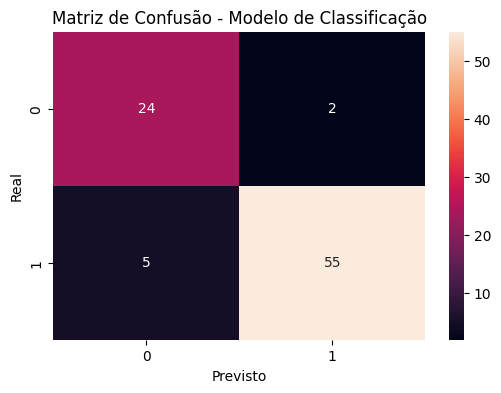

In [55]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Modelo de Classificação')

plt.show()

In [57]:
novo = X.iloc[[0]]  # mantém formato DataFrame

pred = model.predict(novo)

print("Classe prevista:", pred[0])

Classe prevista: 0


## Predição Final

In [39]:
novo_processo = pd.DataFrame({
    'valor_causa': [90000],
    'dias_prazo': [2],
    'urgencia': [1],
    'qtd_partes': [5],
    'tempo_parado': [1]
})

predicao = model.predict(novo_processo)

resultado = le.inverse_transform(predicao)

print("Prioridade prevista:", resultado[0])

Prioridade prevista: Alta


## Conclusão

O projeto demonstrou a aplicação prática de Machine Learning na gestão jurídica, permitindo automatizar a priorização de processos com base em critérios estratégicos.

A solução pode auxiliar escritórios de advocacia na melhoria da produtividade e organização processual.